# 📊 GroupBy & Aggregate Functions in Pandas

---

## 🔹 What is GroupBy?

In Python’s **pandas** library, the `.groupby()` function is a powerful and essential tool used for **data analysis and summarization**.

It follows the concept of:

> 🧩 **Split → Apply → Combine**

- **Split**: Divide the dataset into groups based on one or more columns  
- **Apply**: Perform operations (like calculations) on each group  
- **Combine**: Merge the results back into a structured output  

---

## 🔍 Definition

The `.groupby()` function is used to **group data based on specific columns** and then apply functions to each group independently, returning aggregated results.

---

## ⚙️ Why Use GroupBy?

✔️ To analyze patterns in data  
✔️ To summarize large datasets  
✔️ To perform calculations on subsets instead of the entire dataset  
✔️ To generate insights quickly and efficiently  

---

## 📈 Aggregate Functions

Aggregate functions are used with `.groupby()` to perform calculations on grouped data.

### 🔢 Common Aggregate Functions:

- 🔹 **COUNT()** → Counts the number of values  
- 🔹 **SUM()** → Calculates total sum  
- 🔹 **AVG() / MEAN()** → Finds average value  
- 🔹 **MAX()** → Finds maximum value  
- 🔹 **MIN()** → Finds minimum value  

---

## 🧠 Example Concept

When using `.groupby()`, instead of analyzing the entire dataset, you can analyze **each category separately**.

👉 Example:
- Group sales data by **Region**
- Then calculate total sales for each region

---

## 🚀 Key Takeaway

💡 `.groupby()` helps you transform raw data into meaningful insights by applying operations **group-wise instead of globally**.

---


In [2]:
import pandas as pd

In [4]:
df_cars = pd.read_csv(r"C:\Users\owais\Downloads\Car_sales.csv")

In [5]:
df_cars

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [6]:
df_cars.columns

Index(['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor'],
      dtype='str')

In [8]:
df_cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

In [9]:
df_cars.describe()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [10]:
df_cars.nunique()

Manufacturer            30
Model                  156
Sales_in_thousands     157
__year_resale_value    117
Vehicle_type             2
Price_in_thousands     152
Engine_size             31
Horsepower              66
Wheelbase               88
Width                   78
Length                 127
Curb_weight            147
Fuel_capacity           55
Fuel_efficiency         20
Latest_Launch          130
Power_perf_factor      154
dtype: int64

### agg()

In [11]:
df_cars.agg('sum')

Manufacturer           AcuraAcuraAcuraAcuraAudiAudiAudiBMWBMWBMWBuick...
Model                  IntegraTLCLRLA4A6A8323i328i528iCenturyRegalPar...
Sales_in_thousands                                              8320.698
__year_resale_value                                              2186.83
Vehicle_type           PassengerPassengerPassengerPassengerPassengerP...
Price_in_thousands                                              4245.567
Engine_size                                                        477.5
Horsepower                                                       29008.0
Wheelbase                                                        16768.0
Width                                                            11099.4
Length                                                           29225.6
Curb_weight                                                      523.594
Fuel_capacity                                                     2800.5
Fuel_efficiency                                    

### group()

In [12]:
df_cars.groupby('Vehicle_type')['Sales_in_thousands'].mean()

Vehicle_type
Car          80.622293
Passenger    43.234345
Name: Sales_in_thousands, dtype: float64

In [13]:
df_cars.groupby('Vehicle_type')[['Sales_in_thousands', 
                                'Price_in_thousands', 
                                'Engine_size', 
                                'Horsepower', 
                                'Fuel_capacity']].mean()

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Vehicle_type,,,,,
Car,80.622293,26.319975,3.520000,186.400000,21.895000
Passenger,43.234345,27.763200,2.902586,185.793103,16.592241


### 📊 Visualization()

### Sales by Manufactures (Bar Chart)

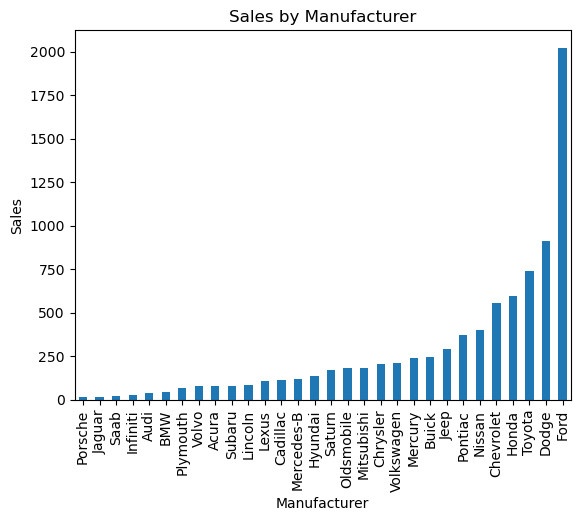

In [23]:
import matplotlib.pyplot as plt

df_cars.groupby('Manufacturer')['Sales_in_thousands'].sum().sort_values().plot(kind='bar')

plt.title('Sales by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Sales')
plt.show()

### Simple Price Distribution (Pie Chart)

In [43]:
bins = [0, 20, 40, 60, 100]
labels = ['Low', 'Medium', 'High', 'Premium']

df_cars['Price_Category'] = pd.cut(df_cars['Price_in_thousands'], bins=bins, labels=labels)

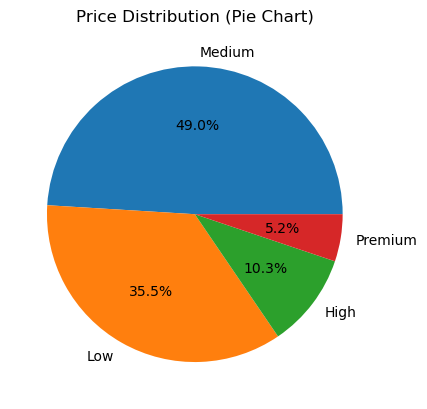

In [44]:
import matplotlib.pyplot as plt

df_cars['Price_Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Price Distribution (Pie Chart)')
plt.ylabel('')
plt.show()

### Price  vs Horsepower(Scatter Plot)

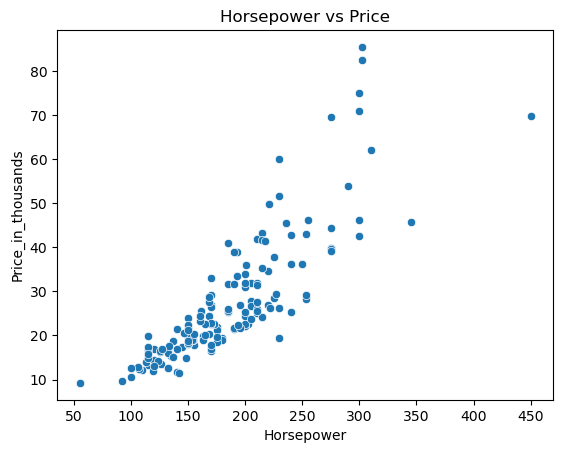

In [29]:
sns.scatterplot(x='Horsepower', y='Price_in_thousands', data=df_cars)
plt.title('Horsepower vs Price')
plt.show()

### Engine Size vs Fuel Efficiency 

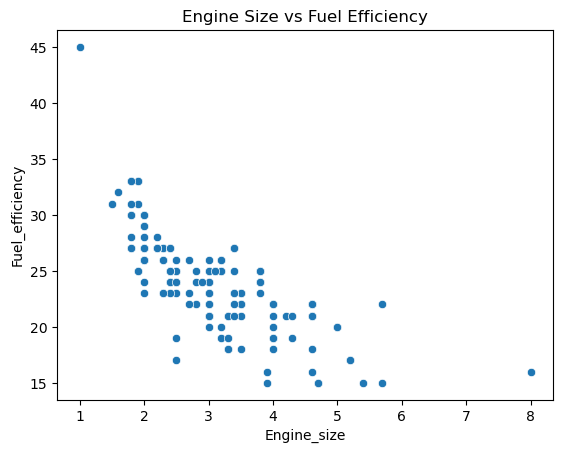

In [30]:
sns.scatterplot(x='Engine_size', y='Fuel_efficiency', data=df_cars)
plt.title('Engine Size vs Fuel Efficiency')
plt.show()

### Correlation Heatmap

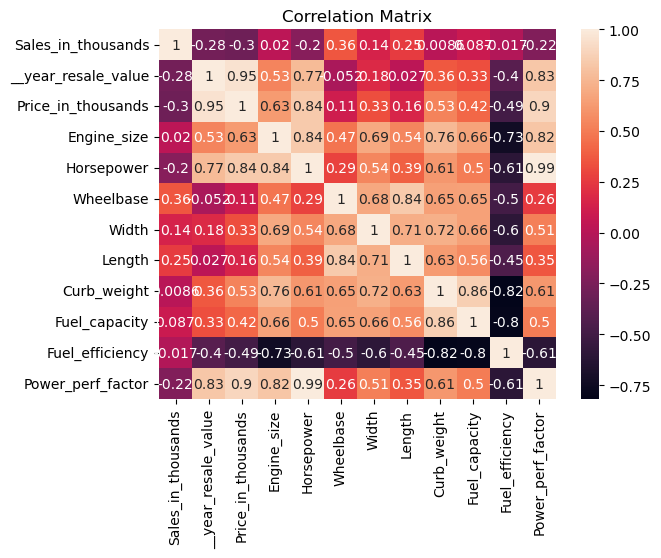

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
df_numeric = df_cars.select_dtypes(include=['number'])

# Create heatmap
sns.heatmap(df_numeric.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

### Top 10 Expensive Cars

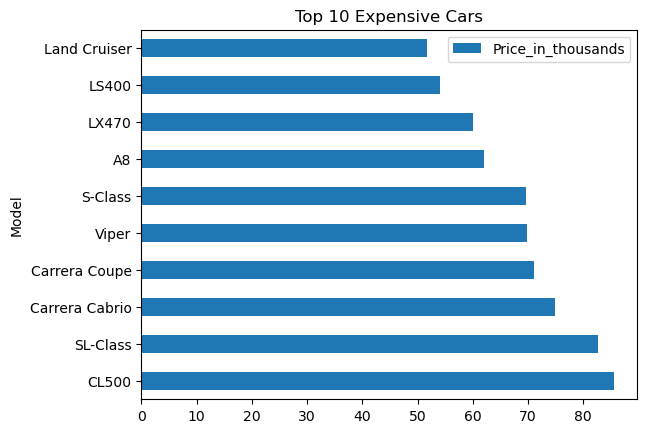

In [37]:
df_cars.nlargest(10, 'Price_in_thousands').plot(kind='barh', x='Model', y='Price_in_thousands')

plt.title('Top 10 Expensive Cars')
plt.show()

### Vehicle Type Count

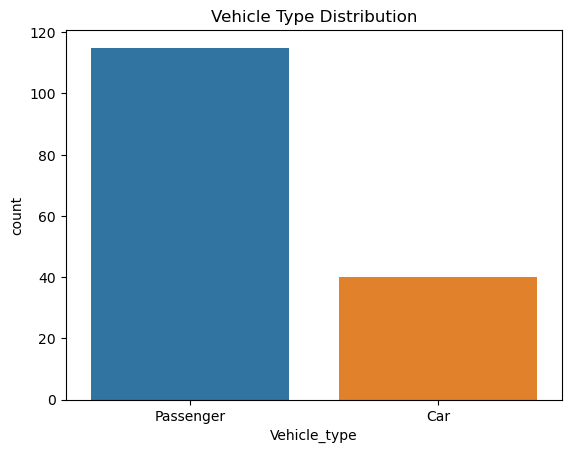

In [38]:
sns.countplot(x='Vehicle_type', data=df_cars)
plt.title('Vehicle Type Distribution')
plt.show()

### Histrogram

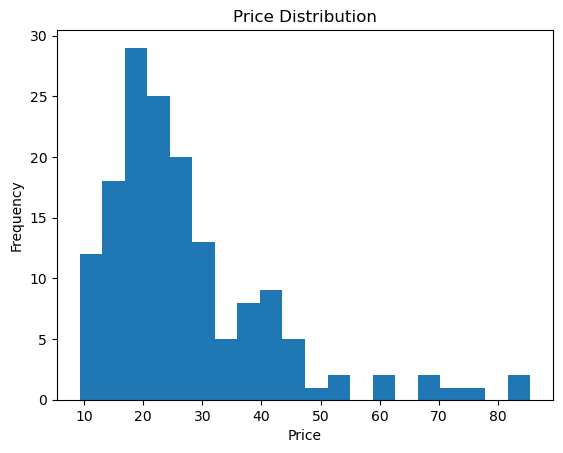

In [39]:
import matplotlib.pyplot as plt

plt.hist(df_cars['Price_in_thousands'].dropna(), bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Box Plot

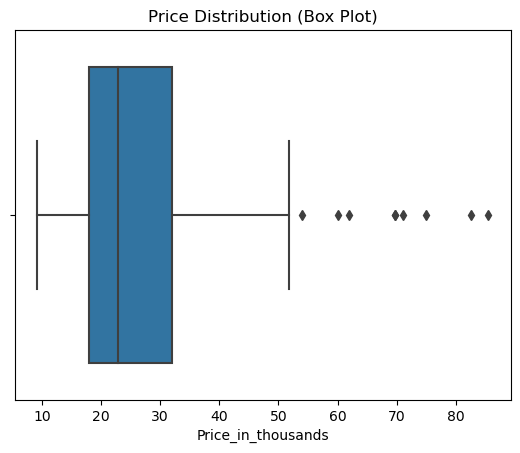

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_cars['Price_in_thousands'])
plt.title('Price Distribution (Box Plot)')
plt.show()

### Violin Plot

# 🎻 What is a Violin Plot?

A **Violin Plot** is a data visualization that shows the **distribution of data**.

👉 It combines:
- 📊 **Box Plot** (median, spread)
- 📈 **Density Plot** (shape of data distribution)

👉 **Simple Definition:**  
A violin plot shows **how data is spread and where values are concentrated**.

---

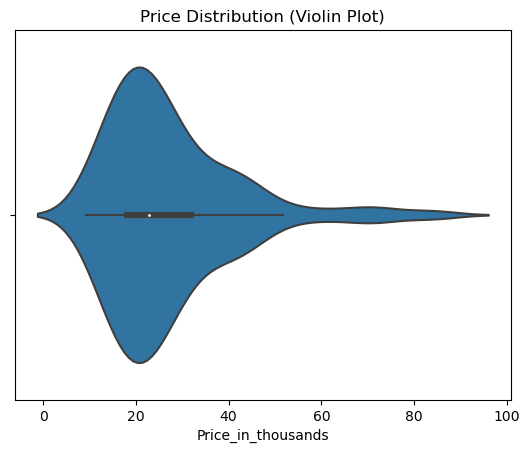

In [41]:
sns.violinplot(x=df_cars['Price_in_thousands'])
plt.title('Price Distribution (Violin Plot)')
plt.show()

### Price By Maunfacturer

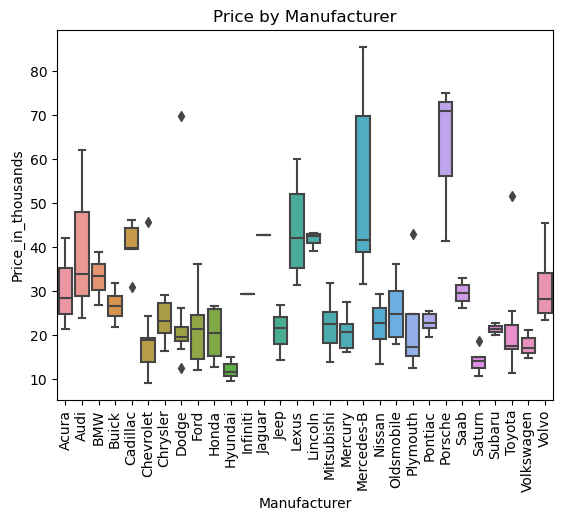

In [46]:
sns.boxplot(x='Manufacturer', y='Price_in_thousands', data=df_cars)
plt.xticks(rotation=90)
plt.title('Price by Manufacturer')
plt.show()

# 🚗 Automobile Market Analysis

- 🧹 Cleaned data and handled missing values  
- 📊 Analyzed relationships between price, horsepower, engine size, and fuel efficiency  
- 📈 Created visualizations using Matplotlib & Seaborn  
- 🏭 Identified sales trends across manufacturers  
- 📉 Studied price distribution using bar, box, and pie charts  

---

## 🎯 Conclusion
- 📊 Provides insights into car pricing and performance  
- 💡 Helps in data-driven decision making  

---

In [47]:
import os

In [48]:
os.getcwd()

'C:\\Users\\owais'